# Analisis Segmentasi Pelanggan (RFM & K-Means)

**Tujuan:** Notebook ini akan memandu Anda melalui seluruh proses analisis segmentasi pelanggan berdasarkan proposal proyek, mulai dari memuat data mentah hingga mengidentifikasi segmen pelanggan yang dapat ditindaklanjuti.

**Alur Kerja:**
1.  **Part 1: Data Loading & Preparation** - Menggabungkan semua file Excel dan menghitung metrik RFM.
2.  **Part 2: Exploratory Data Analysis (EDA) & Preprocessing** - Memahami, memvisualisasikan, dan mempersiapkan data RFM untuk clustering.
3.  **Part 3: K-Means Clustering** - Menemukan jumlah cluster yang optimal dan menerapkan algoritma K-Means.
4.  **Part 4: Cluster Analysis & Interpretation** - Menganalisis dan memberi nama setiap segmen pelanggan.

## Part 1: Data Loading & RFM Calculation

In [1]:
import pandas as pd
import glob
import os
import datetime as dt
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Mengatur agar semua kolom ditampilkan saat memanggil .head() atau .info()
pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

Libraries imported successfully!


**Load and Merge Transaction Data**
Kode ini akan mencari semua file Excel di folder `../dataset/`, membacanya, dan menggabungkannya menjadi satu DataFrame

In [2]:
path_ke_dataset = '../dataset/*.xlsx'
file_paths = glob.glob(path_ke_dataset)
if not file_paths:
  print("Tidak ada file Excel (.xlsx) yang ditemukan di folder dataset.")
else:
  print("Ditemukan {len(file_paths)} file untuk digabungkan:")
list_of_dataframes = []
for path in file_paths:
  try:
    print("- Membaca {os.path.basename(path)}...")
    df = pd.read_excel(path, skiprows=4)
    list_of_dataframes.append(df)
  except Exception as e:
    print("Error saat membaca file {path}: {e}")
 # Gabungkan semua dataframe
df_merged = pd.concat(list_of_dataframes, ignore_index=True)
print("Semua file berhasil digabungkan.")
print("Total baris data setelah digabung: {len(df_merged)}")
display(df_merged.head())

Ditemukan {len(file_paths)} file untuk digabungkan:
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
- Membaca {os.path.basename(path)}...
Semua file berhasil digabungkan.
Total baris data setelah digabung: {len(df_merged)}


,No.,Tgl. Trans.,No. Trans.,Syarat Bayar.,Tgl. Jatuh Tempo,Customer,Total (Rp),PPN (Rp),Biaya Kirim (Rp),Grand Total (Rp),No. SO,No. Konsinyasi,ISBN,ISBN Dtl.,Judul,Satuan,Jml,Harga (Rp),Total Disc (%),Total Disc (Rp),Subtotal (Rp),Catatan,Ekspedisi,No. Resi,Tgl. Kirim
0,1,2017-01-03,J.01.1701.0001,CASH,2017-01-03,YUNICA FITRIANI,30000.0,0.0,0.0,30000.0,NaN,NaN,9786021302217,9786021302217.099609,SOUL KEEPING (MENJAGA JIWA),EX,1.0,60000.0,50.0,30000.0,30000.0,NaN,NaN,NaN,NaN
1,2,2017-01-03,J.01.1701.0002,CASH,2017-01-03,MELINA,124000.0,0.0,0.0,124000.0,NaN,NaN,9786021854754,9786021854754.099609,BAHAN PA : MENCARI KEHENDAK TUHAN,EX,1.0,24000.0,NaN,0.0,24000.0,NaN,NaN,NaN,NaN
2,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9786021854716,9786021854716.099609,JUST DO SOMETHING (LAKUKANLAH SESUATU),EX,1.0,40000.0,NaN,0.0,40000.0,NaN,NaN,NaN,NaN
3,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9766029670097,9766029670097.099609,MEMBENTUK KEROHANIAN ANAK MUDA,EX,1.0,60000.0,NaN,0.0,60000.0,NaN,NaN,NaN,NaN
4,3,2017-01-03,J.01.1701.0003,7 HARI,2017-01-10,IWAN SATRIA,400000.0,0.0,45000.0,445000.0,NaN,NaN,9786021854761,9786021854761.099609,UANG DAN PEKERJAAN,EX,20.0,25000.0,20.0,5000.0,400000.0,NaN,NaN,NaN,NaN


### Calculate RFM Metrics
Membersihkan data transaksi dan mengubahnya menjadi tabel RFM (satu baris per pelanggan)

In [3]:
KOLOM_TANGGAL = 'Tgl. Trans.'
KOLOM_INVOICE = 'No. Trans.'
KOLOM_PELANGGAN = 'Customer'
KOLOM_TOTAL_BELANJA = 'Subtotal (Rp)'

# 1. Pilih kolom yang dibutuhkan dan bersihkan data
df_rfm_prep = df_merged[[KOLOM_TANGGAL, KOLOM_INVOICE, KOLOM_PELANGGAN, KOLOM_TOTAL_BELANJA]].copy()
df_rfm_prep.dropna(subset=[KOLOM_PELANGGAN, KOLOM_TANGGAL], inplace=True)
df_rfm_prep[KOLOM_TANGGAL] = pd.to_datetime(df_rfm_prep[KOLOM_TANGGAL], errors='coerce')
df_rfm_prep[KOLOM_TOTAL_BELANJA] = pd.to_numeric(df_rfm_prep[KOLOM_TOTAL_BELANJA], errors='coerce').fillna(0)
df_rfm_prep.dropna(subset=[KOLOM_TANGGAL], inplace=True)
print("Data berhasil dibersihkan.")

# 2. Hitung nilai RFM
snapshot_date = df_rfm_prep[KOLOM_TANGGAL].max() + dt.timedelta(days=1)
df_rfm = df_rfm_prep.groupby(KOLOM_PELANGGAN).agg({
KOLOM_TANGGAL: lambda date: (snapshot_date - date.max()).days,
KOLOM_INVOICE: 'nunique', # Menggunakan nunique untuk transaksi unik
KOLOM_TOTAL_BELANJA: 'sum'
})

# 3. Ganti nama kolom
df_rfm.rename(columns={
KOLOM_TANGGAL: 'Recency',
KOLOM_INVOICE: 'Frequency',
KOLOM_TOTAL_BELANJA: 'Monetary'
}, inplace=True)

# 4. Filter data yang tidak relevan (misal, pelanggan yang hanya retur atau tidak belanja)
df_rfm = df_rfm[df_rfm['Monetary'] > 0]

print(f"✅ Tabel RFM berhasil dibuat dengan {len(df_rfm)} pelanggan.")
display(df_rfm.head())

Data berhasil dibersihkan.
✅ Tabel RFM berhasil dibuat dengan 16499 pelanggan.


,Recency,Frequency,Monetary
Customer,,,
(PERKANTAS TORAJA UTARA) UP.NIKI,343,6,1149000.0
(VONNI PERONICA),741,1,32500.0
(YEMIMA),846,1,58000.0
12345MAYKEL 230613A669JJWU,551,1,66990.0
180 CHRISTIAN STORE JAKARTA,13,34,2342650.0


In [4]:
# SEL BARU: Feature Engineering - Membuat Metrik Baru

print("Membuat fitur baru dari data RFM...")
df_rfm_engineered = df_rfm.copy()

# Membuat metrik baru: Rata-rata nilai per transaksi
# Menambahkan 1e-6 untuk menghindari pembagian dengan nol jika ada frekuensi 0
df_rfm_engineered['AvgTransactionValue'] = df_rfm_engineered['Monetary'] / (df_rfm_engineered['Frequency'] + 1e-6)

print("✅ Fitur baru 'AvgTransactionValue' berhasil ditambahkan.")
display(df_rfm_engineered.head())

Membuat fitur baru dari data RFM...
✅ Fitur baru 'AvgTransactionValue' berhasil ditambahkan.


,Recency,Frequency,Monetary,AvgTransactionValue
Customer,,,,
(PERKANTAS TORAJA UTARA) UP.NIKI,343,6,1149000.0,191499.968083
(VONNI PERONICA),741,1,32500.0,32499.967500
(YEMIMA),846,1,58000.0,57999.942000
12345MAYKEL 230613A669JJWU,551,1,66990.0,66989.933010
180 CHRISTIAN STORE JAKARTA,13,34,2342650.0,68901.468562


### Part 2: Exploratory Data Analysis (EDA) & Preprocessing

### Analyze RFM Distribution
Memahami distribusi data. Apakah ada nilai yang sangat ekstrim (outliers)? Apakah datanya miring (skewed)? Ini penting karena K-Means sensitif terhadap kedua hal ini.

In [5]:
print("Ringkasan Statistik Data RFM:")
display(df_rfm.describe())

print("Skewness Data RFM:")
print(df_rfm.skew())

Ringkasan Statistik Data RFM:


,Recency,Frequency,Monetary
count,16499.000000,16499.000000,1.649900e+04
mean,1114.611370,1.724408,2.736444e+05
std,728.477879,6.174857,2.735948e+06
min,1.000000,1.000000,2.000000e+03
25%,500.000000,1.000000,5.044000e+04
50%,1045.000000,1.000000,6.405000e+04
75%,1614.000000,1.000000,1.020000e+05
max,2920.000000,383.000000,2.222586e+08


Skewness Data RFM:
Recency       0.424746
Frequency    34.918178
Monetary     45.624076
dtype: float64


### Visualize RFM Distribution
Visualisasi dengan Boxplot untuk melihat outliers. Titik-titik di luar "kumis" plot adalah outliers."

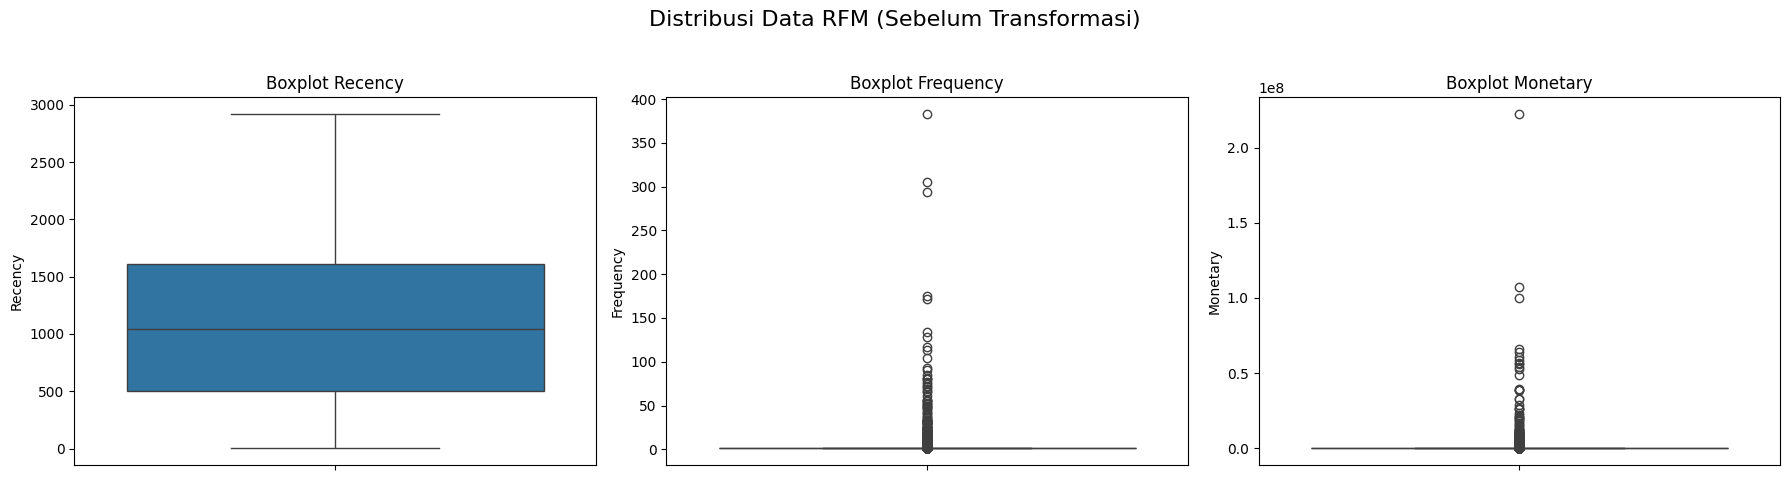

In [6]:
plt.figure(figsize=(18, 5))
plt.suptitle('Distribusi Data RFM (Sebelum Transformasi)', fontsize=16)

# Boxplot untuk Recency
plt.subplot(1, 3, 1)
sns.boxplot(y=df_rfm['Recency'])
plt.title('Boxplot Recency')

# Boxplot untuk Frequency
plt.subplot(1, 3, 2)
sns.boxplot(y=df_rfm['Frequency'])
plt.title('Boxplot Frequency')

# Boxplot untuk Monetary
plt.subplot(1, 3, 3)
sns.boxplot(y=df_rfm['Monetary'])
plt.title('Boxplot Monetary')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

###  Data Transformation and Scaling
Karena data kita highly skewed dan memiliki skala yang berbeda, maka dilakukan:
1.  **Log Transformation**: Untuk mengurangi efek skewness dan outliers.
2.  **Standard Scaling**: Untuk membawa semua variabel ke skala yang sama (rata-rata 0, standar deviasi 1).

In [5]:
# --- GANTI SEL LAMA ANDA DENGAN INI ---
# Cell 6: Data Transformation and Scaling (dengan Fitur Baru)

# Pilih fitur yang akan digunakan untuk clustering
features_for_clustering = ['Recency', 'Frequency', 'Monetary', 'AvgTransactionValue']
df_for_clustering = df_rfm_engineered[features_for_clustering]

# 1. Log Transformation
df_log = np.log1p(df_for_clustering)

# 2. Standard Scaling
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_log)

# Konversi hasil scaling kembali ke DataFrame
df_prepared_engineered = pd.DataFrame(scaled_array, index=df_for_clustering.index, columns=df_for_clustering.columns)

print("Data dengan fitur baru berhasil ditransformasi dan di-scaling.")
display(df_prepared_engineered.head())

Data dengan fitur baru berhasil ditransformasi dan di-scaling.


,Recency,Frequency,Monetary,AvgTransactionValue
Customer,,,,
(PERKANTAS TORAJA UTARA) UP.NIKI,-0.741374,2.922447,2.812270,1.457547
(VONNI PERONICA),-0.036634,-0.368254,-0.956209,-0.934356
(YEMIMA),0.084703,-0.368254,-0.344026,-0.153263
12345MAYKEL 230613A669JJWU,-0.307820,-0.368254,-0.191720,0.041067
180 CHRISTIAN STORE JAKARTA,-3.676538,7.150045,3.565242,0.079010


## Part 3: K-Means Clustering

### Find Optimal Number of Clusters (Elbow Method)
Kita akan menjalankan K-Means untuk beberapa jumlah cluster (K) dan melihat di mana penambahan cluster baru tidak lagi memberikan banyak penurunan pada *inertia* (Within-Cluster Sum of Squares). Titik ini disebut "siku" (elbow).

Menghitung Inertia dan Silhouette Score untuk setiap K (dengan fitur baru)...
Untuk K=2, Silhouette Score adalah: 0.5528
Untuk K=3, Silhouette Score adalah: 0.3799
Untuk K=4, Silhouette Score adalah: 0.4076
Untuk K=5, Silhouette Score adalah: 0.4076
Untuk K=6, Silhouette Score adalah: 0.3629
Untuk K=7, Silhouette Score adalah: 0.3836
Untuk K=8, Silhouette Score adalah: 0.3817
Untuk K=9, Silhouette Score adalah: 0.3912
Untuk K=10, Silhouette Score adalah: 0.3691


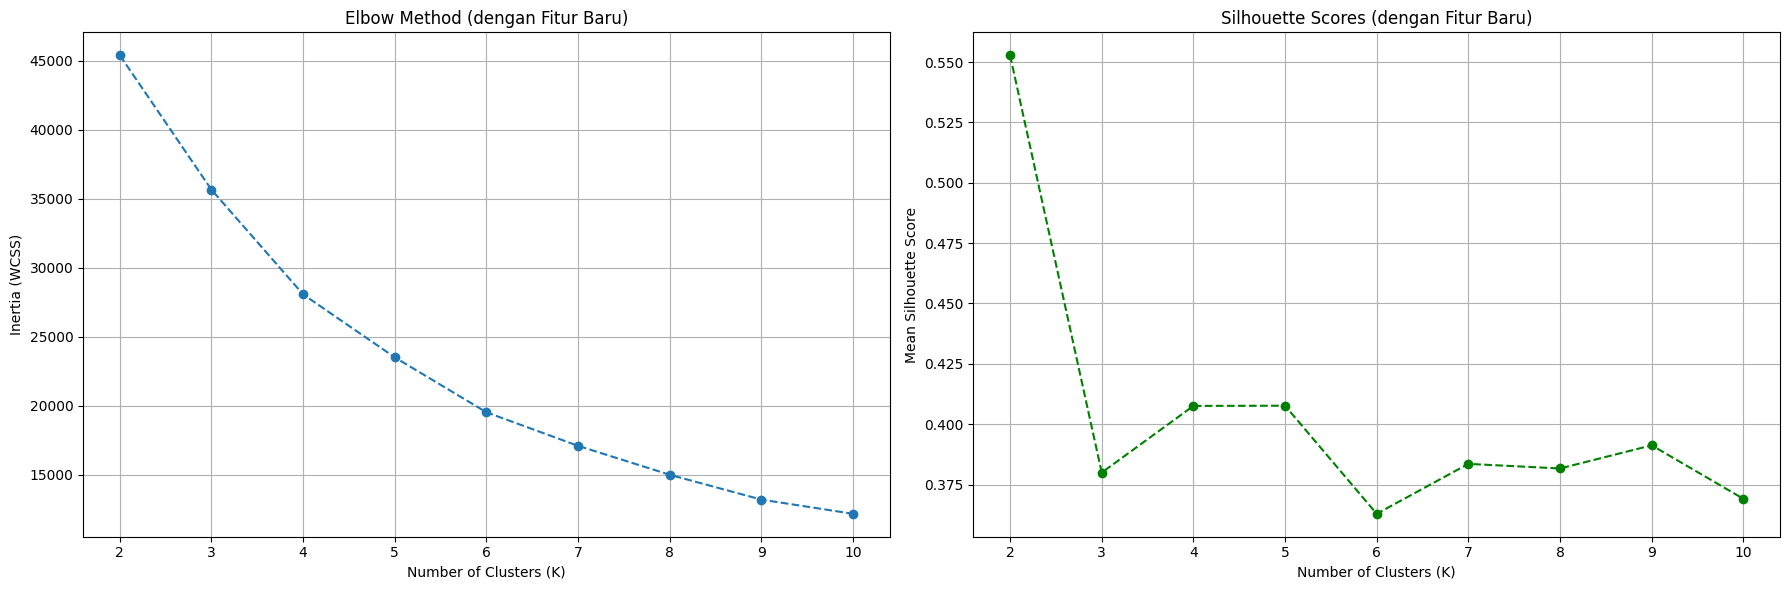

In [6]:
# --- GANTI SEL LAMA ANDA DENGAN INI ---
# Cell 7: Find Optimal Number of Clusters (dengan Fitur Baru)

from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
range_k = range(2, 11)

print("Menghitung Inertia dan Silhouette Score untuk setiap K (dengan fitur baru)...")
for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Gunakan data baru yang sudah disiapkan: df_prepared_engineered
    kmeans.fit(df_prepared_engineered)
    
    inertia.append(kmeans.inertia_)
    score = silhouette_score(df_prepared_engineered, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"Untuk K={k}, Silhouette Score adalah: {round(score, 4)}")

# Buat plot
plt.figure(figsize=(18, 6))

# Plot 1: Elbow Method
plt.subplot(1, 2, 1)
plt.plot(range_k, inertia, marker='o', linestyle='--')
plt.title('Elbow Method (dengan Fitur Baru)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)

# Plot 2: Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(range_k, silhouette_scores, marker='o', linestyle='--', color='g')
plt.title('Silhouette Scores (dengan Fitur Baru)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Mean Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

### Apply K-Means Clustering
Berdasarkan grafik Elbow, kita akan memilih jumlah K yang optimal (biasanya 3, 4, atau 5 adalah pilihan yang baik untuk segmentasi RFM). Kemudian kita terapkan K-Means dengan K tersebut.

In [ ]:
# Pilih K yang optimal dari grafik Elbow (misalnya, K=4)
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(df_rfm_prepared)

# Tambahkan label cluster ke DataFrame RFM asli (yang belum di-scaling)
df_rfm['Cluster'] = kmeans.labels_

print(f"✅ Clustering selesai dengan K={optimal_k}.")
display(df_rfm.head())

✅ Clustering selesai dengan K=4.


,Recency,Frequency,Monetary,Cluster
Customer,,,,
(PERKANTAS TORAJA UTARA) UP.NIKI,343,6,1149000.0,2
(VONNI PERONICA),741,1,32500.0,0
(YEMIMA),846,1,58000.0,0
12345MAYKEL 230613A669JJWU,551,1,66990.0,0
180 CHRISTIAN STORE JAKARTA,13,34,2342650.0,2


In [12]:
# Hitung jumlah pelanggan di setiap cluster dan urutkan berdasarkan nomor cluster
cluster_distribution = df_rfm['Cluster'].value_counts().sort_index()

print("\nDistribusi Pelanggan per Cluster:")
print(cluster_distribution)


Distribusi Pelanggan per Cluster:
Cluster
0    10073
1     2949
2      500
3     2977
Name: count, dtype: int64


C:\Users\Jessica Chandra\AppData\Local\Temp\ipykernel_18020\3495592881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df_rfm, palette='viridis')


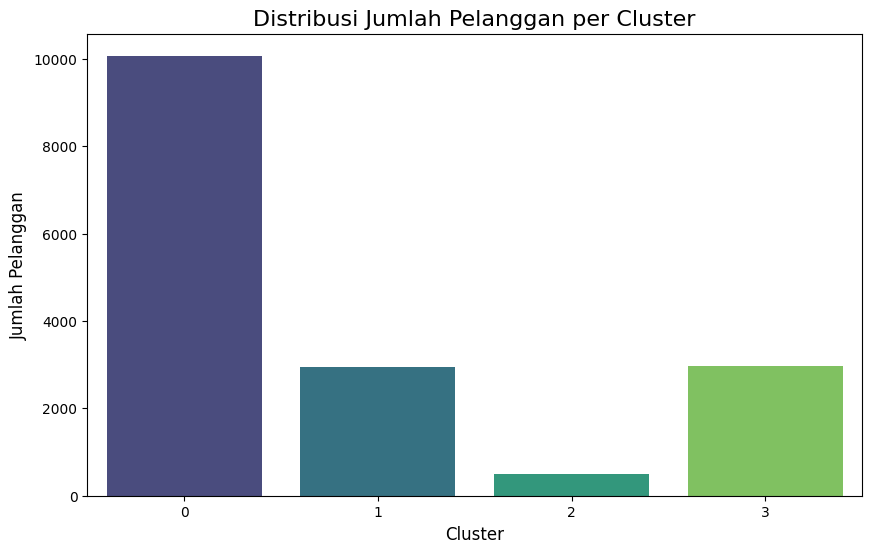

In [13]:
# Visualisasikan distribusi dengan bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=df_rfm, palette='viridis')
plt.title('Distribusi Jumlah Pelanggan per Cluster', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)
plt.show()

In [14]:
from sklearn.metrics import silhouette_score

# df_rfm_prepared adalah data yang sudah di-scaling yang Anda gunakan untuk K-Means
# kmeans.labels_ adalah hasil cluster dari setiap pelanggan

# Hitung Mean Silhouette Score
silhouette_avg = silhouette_score(df_rfm_prepared, kmeans.labels_)

print(f"Mean Silhouette Score untuk K={optimal_k} adalah: {silhouette_avg}")

Mean Silhouette Score untuk K=4 adalah: 0.45028691380559166


### Profile the Clusters
Memahami karakteristik setiap cluster. Kita akan menghitung rata-rata R, F, dan M untuk setiap cluster.

In [10]:
cluster_profile = df_rfm.groupby('Cluster').agg({
  'Recency': 'mean',
  'Frequency': 'mean',
  'Monetary': 'mean',
}).round(2)
    
print("Profil Rata-rata per Cluster:")
display(cluster_profile)

Profil Rata-rata per Cluster:


,Recency,Frequency,Monetary
Cluster,,,
0,1325.99,1.03,59430.72
1,178.89,1.05,84707.70
2,882.49,16.69,4605158.51
3,1365.28,2.24,458122.58


### Visualize the Clusters
Memvisualisasikan profil cluster supaya lebih mudah untuk dibandingkan.

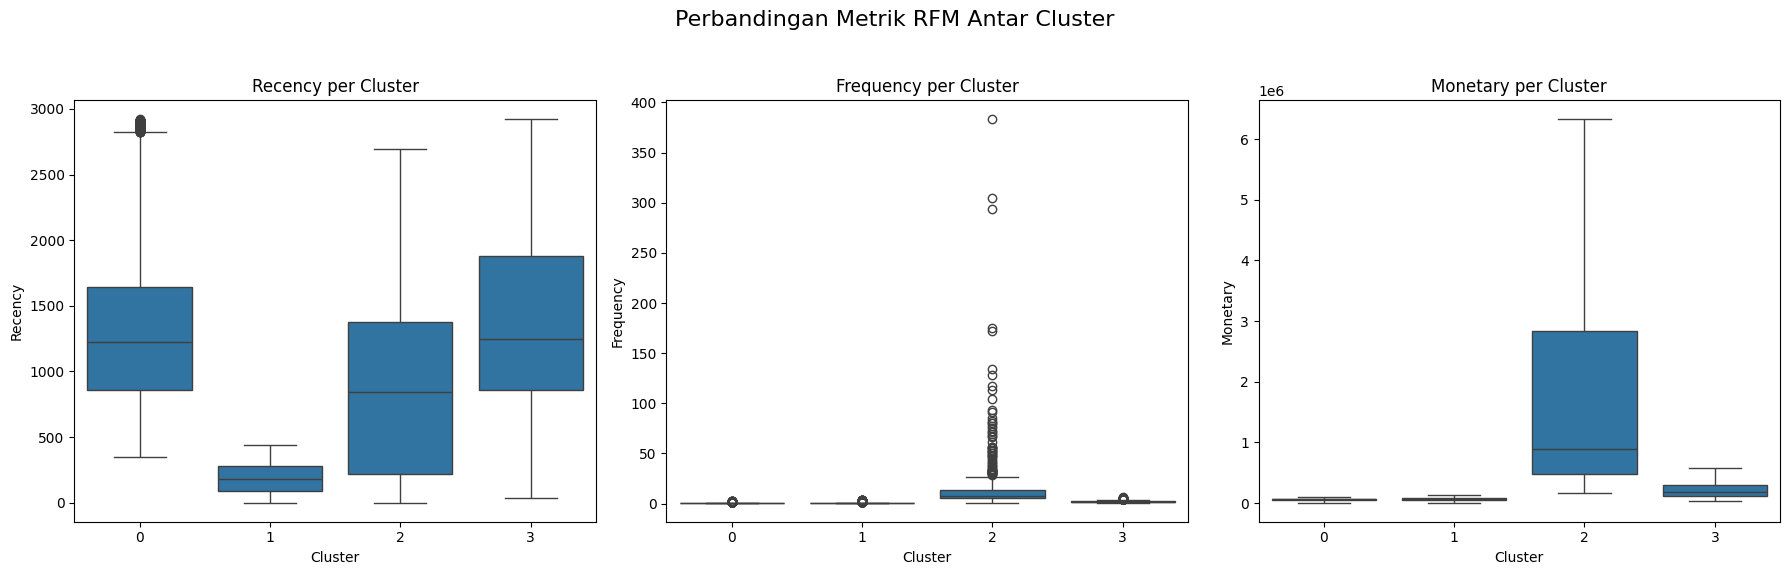

In [11]:
plt.figure(figsize=(18, 6))
plt.suptitle('Perbandingan Metrik RFM Antar Cluster', fontsize=16)

# Plot Recency
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Recency', data=df_rfm)
plt.title('Recency per Cluster')

# Plot Frequency
plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Frequency', data=df_rfm)
plt.title('Frequency per Cluster')

# Plot Monetary
plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='Monetary', data=df_rfm, showfliers=False) # Hapus outliers agar lebih mudah dibaca
plt.title('Monetary per Cluster')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Interpretasi dan Penamaan Segmen
Berdasarkan profil dan visualisasi, kita sekarang dapat memberi nama pada setiap segmen.
  - **Recency Rendah** = Baik (Baru saja belanja)
  - **Frequency Tinggi** = Baik (Sering belanja)
  - **Monetary Tinggi** = Baik (Banyak belanja)